In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import string
import datetime
import seaborn as sns

In [2]:
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import re
from folium import plugins
from folium.plugins import HeatMap
import geopandas as gpd
from geopy.distance import geodesic
from shapely.geometry import Point, Polygon, MultiPolygon
from mpl_toolkits.axes_grid1 import make_axes_locatable
import math

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Data

In [ ]:
data=pd.read_excel('../Data/water_wea_ili.xlsx')
data

,date,viral_mean,year,week,ILI,avgtem,mintem,maxtem,rain,wind,hum
0,2023-01-07,1.341490e+17,2023,1,52.50000,-0.011128,-4.991128,5.696541,1.296835,1.918045,58.908421
1,2023-01-14,2.065967e+16,2023,2,40.20000,4.776981,-0.636472,11.193124,12.017021,1.468012,74.538714
2,2023-01-21,1.778270e+17,2023,3,28.30000,-0.855655,-5.153720,3.821280,1.843891,2.198206,63.707292
3,2023-01-28,1.075471e+17,2023,4,25.60000,-4.274367,-9.306399,1.174702,1.338889,2.565476,56.108495
4,2023-02-04,2.560581e+16,2023,5,17.00000,0.547612,-4.836418,6.493284,0.347222,1.981024,54.461019
...,...,...,...,...,...,...,...,...,...,...,...
97,2024-11-16,1.724794e+13,2024,46,4.60000,13.977729,9.340353,20.255965,1.339098,1.248012,78.305015
98,2024-11-23,3.612775e+14,2024,47,4.80000,7.341532,2.130781,13.132990,1.165854,1.977761,62.125037
99,2024-11-30,1.138406e+14,2024,48,5.34375,5.964148,1.679142,10.656953,6.752632,2.577434,71.175847
100,2024-12-07,1.397429e+15,2024,49,6.84375,5.087001,0.566224,10.259587,0.542798,2.061856,62.667010


## Figure. Data description

In [6]:
# times new roman 폰트로 변경

plt.rcParams['font.family'] = 'Times New Roman'

In [7]:
set_dpi=600

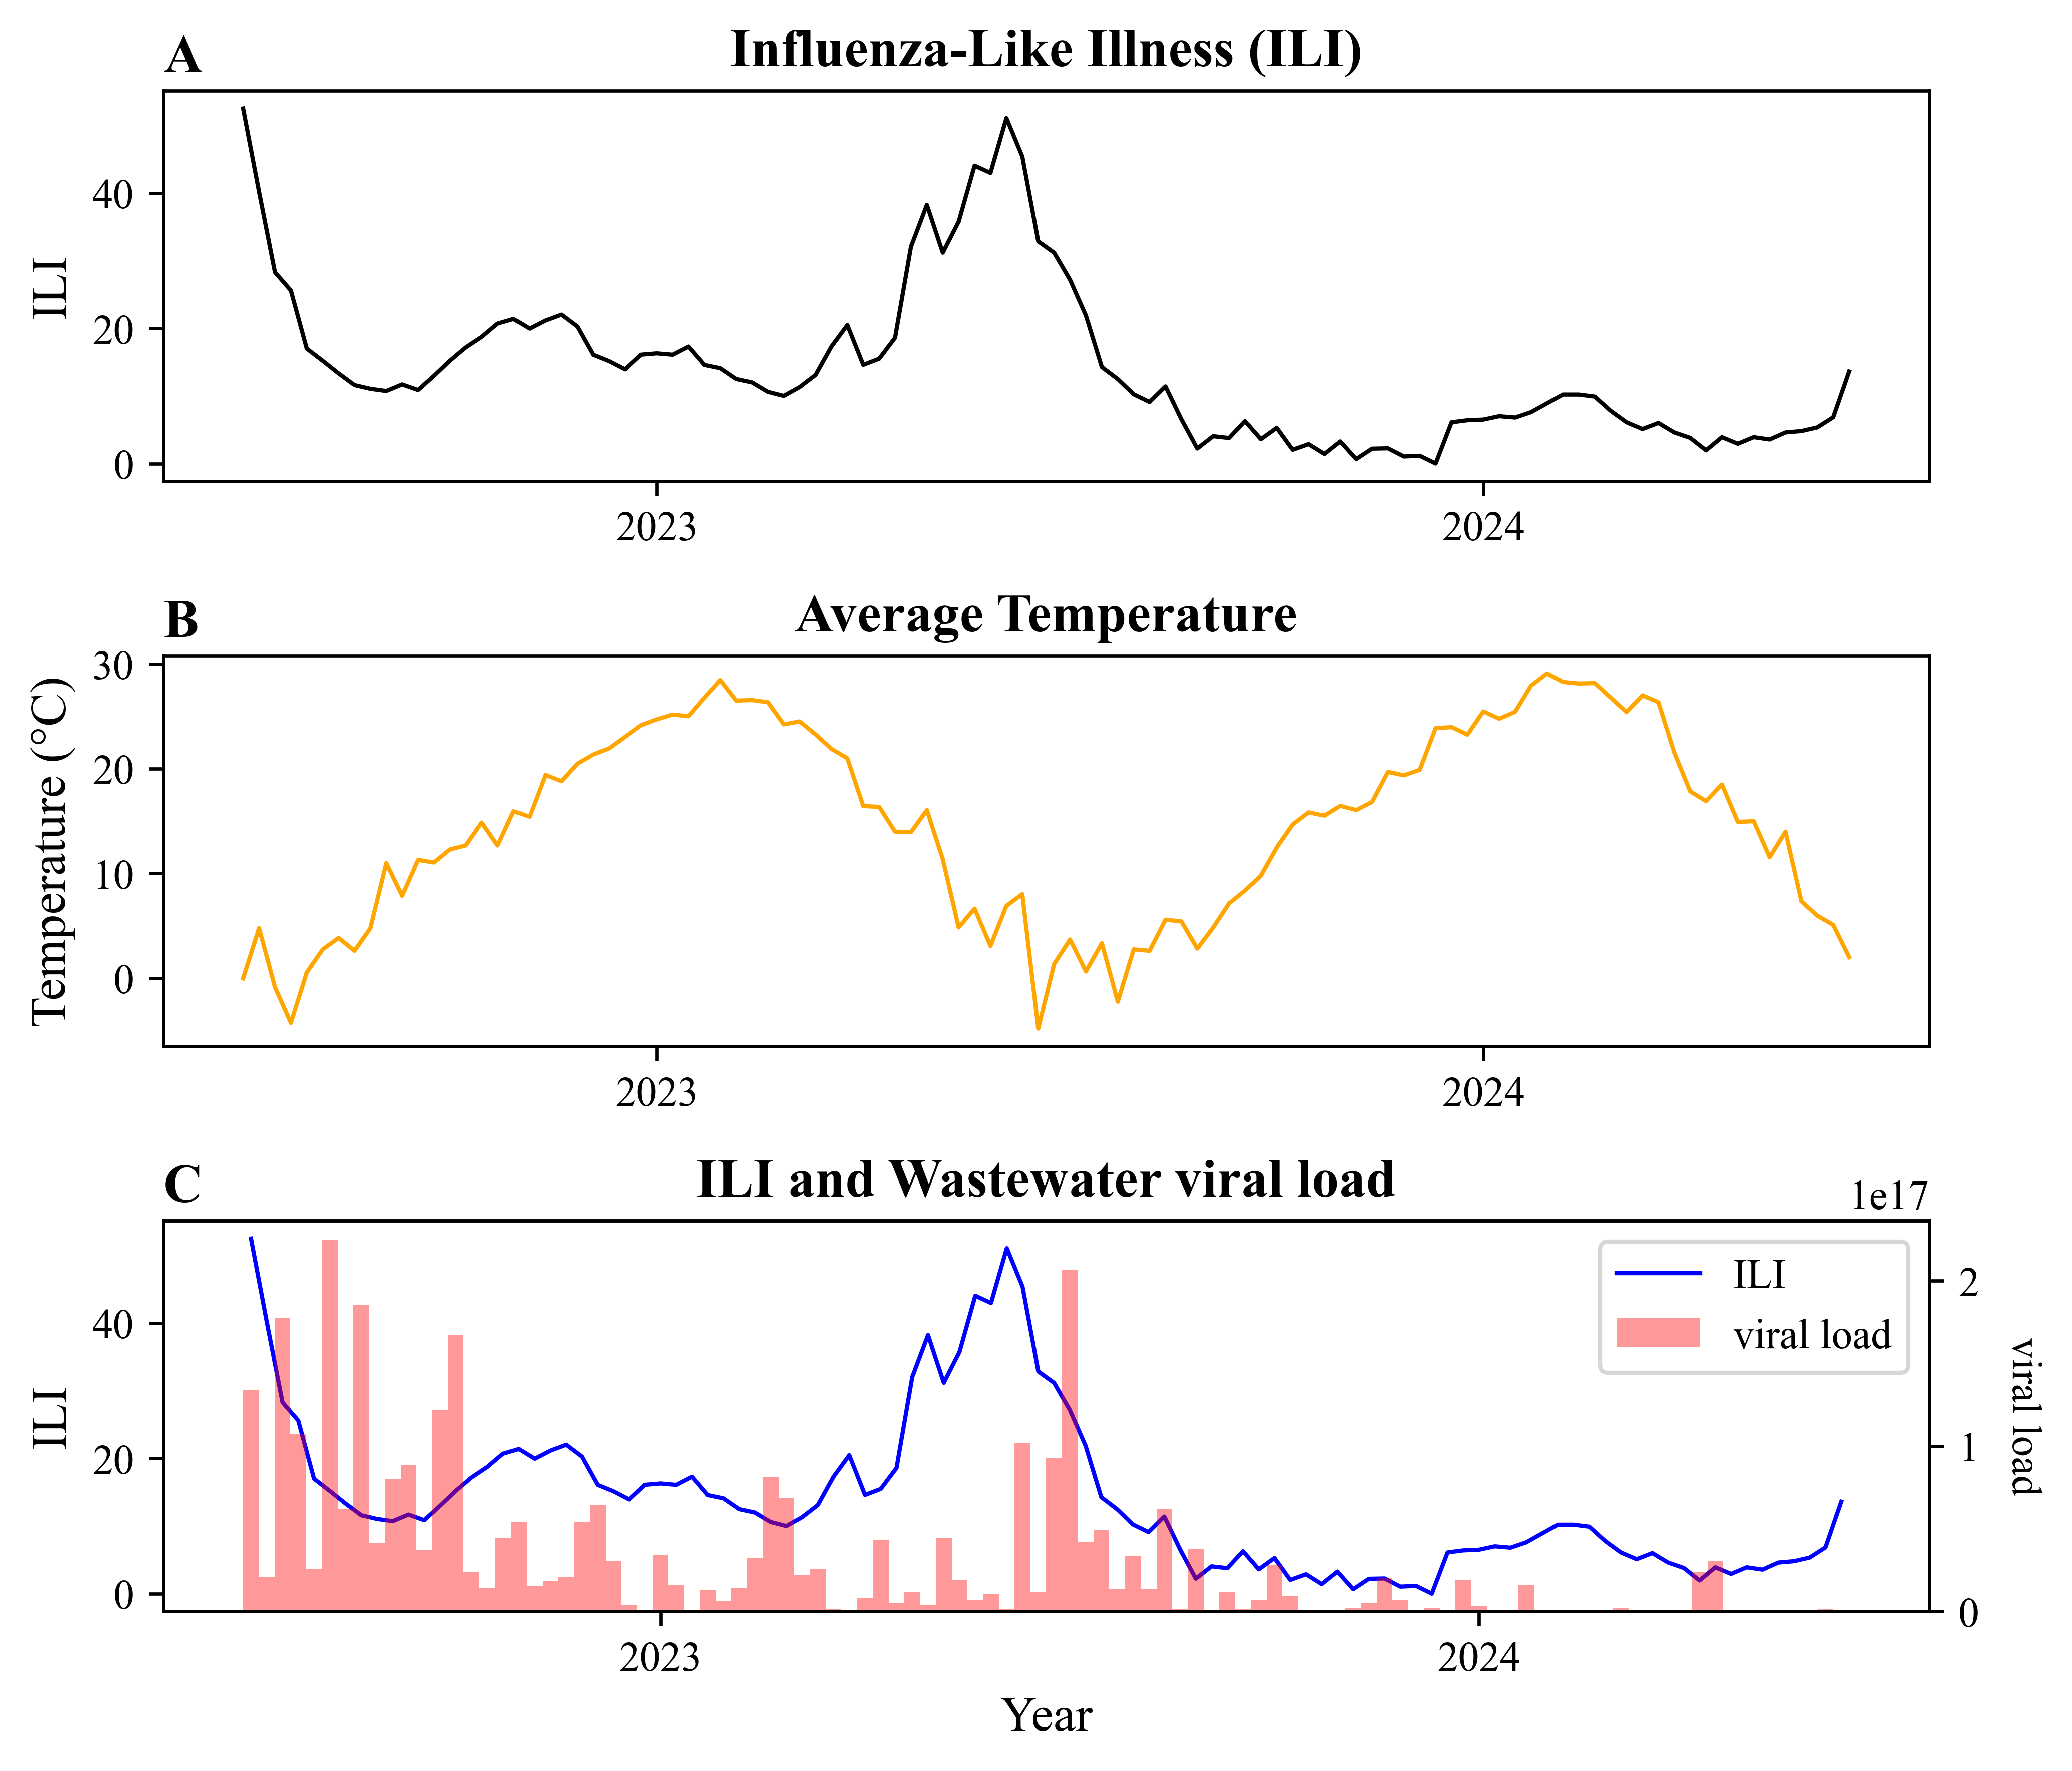

In [8]:
fig, ax=plt.subplots(3,1,figsize=(7,6), dpi=set_dpi)

i=0
ax[i].plot(data.index, data['ILI'], color='black', label='ILI', linewidth=1)
ax[i].set_ylabel('ILI', fontsize=12)
# ax[i].set_xlabel('Year')
ax[i].set_title('Influenza-Like Illness (ILI)', fontweight='bold', fontsize=13)
ax[i].set_xticks(data.index[26::52], data['year'][26::52])
ax[i].text(0,1.05,'{}'.format(string.ascii_uppercase[i]),transform=ax[i].transAxes,weight='bold',fontsize=13) 

i=1
ax[i].plot(data.index, data['avgtem'], color='orange', label='Temperature', linewidth=1)
ax[i].set_ylabel('Temperature (°C)', fontsize=12)
# ax[i].set_xlabel('Year')
ax[i].set_title('Average Temperature', fontweight='bold', fontsize=13)
ax[i].set_xticks(data.index[26::52], data['year'][26::52])
ax[i].text(0,1.05,'{}'.format(string.ascii_uppercase[i]),transform=ax[i].transAxes,weight='bold',fontsize=13) 

i=2
ax2=ax[i].twinx()

ax[i].plot(data.index, data['ILI'], color='blue', label='ILI', linewidth=1)
ax2.bar(data.index, data['viral_mean'], color='red', label='viral load', width=1, alpha=0.4)
ax[i].set_ylabel('ILI', fontsize=12)
ax2.set_ylabel('viral load', rotation=270, labelpad=15)
ax[i].set_xlabel('Year', fontsize=12) 
ax[i].set_title('ILI and Wastewater viral load', fontweight='bold', fontsize=13)
ax[i].set_xticks(data.index[26::52], data['year'][26::52])
ax[i].text(0,1.05,'{}'.format(string.ascii_uppercase[i]),transform=ax[i].transAxes,weight='bold',fontsize=13) 

# legend
lines, labels = ax[i].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines=lines+lines2
labels=labels+labels2
ax[i].legend(lines, labels, loc='upper right')

fig.tight_layout()
plt.savefig("../figure/figure 2.png", dpi=set_dpi, bbox_inches=None, pad_inches=0)
plt.show()


## Figure. correlation matrix

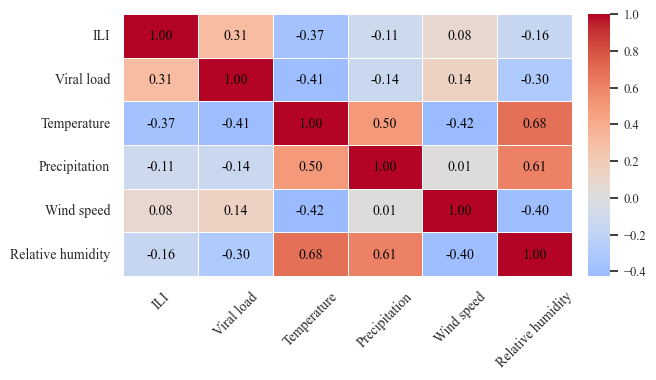

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# 열 이름 매핑 (보기에 더 예쁜 이름으로)
rename_dict = {
    'ILI': 'ILI',
    'viral_mean': 'Viral load',
    'avgtem': 'Temperature',
    'rain': 'Precipitation',
    'wind': 'Wind speed',
    'hum': 'Relative humidity'
}

# 열 이름 변경
data_cor = data[['ILI', 'viral_mean', 'avgtem', 'rain', 'wind', 'hum']].rename(columns=rename_dict)
corr_matrix = data_cor.corr()

# 스타일 설정
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['font.family'] = 'Times New Roman'

# 그림 사이즈
plt.figure(figsize=(7, 4))

# 히트맵 그리기
heatmap=sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    annot_kws={"size": 10, "color": "black"},
    cbar_kws={"shrink": 1, "aspect": 12, "pad": 0.03}
)

# x축, y축 label 폰트 크기 조정
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)

# 컬러바 접근 후 글자 크기 조정
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)

# 컬러바 눈금: 위아래 끝 숫자까지 포함되도록 설정
cbar.locator = MaxNLocator(nbins=8)  # 눈금 개수 설정
cbar.update_ticks()  # 설정 적용

# 제목
# plt.title('Correlation Heatmap', fontsize=15, pad=12, weight='bold')

plt.tight_layout()
plt.show()


## 2023-24 결과 figure(실데이터 사용)

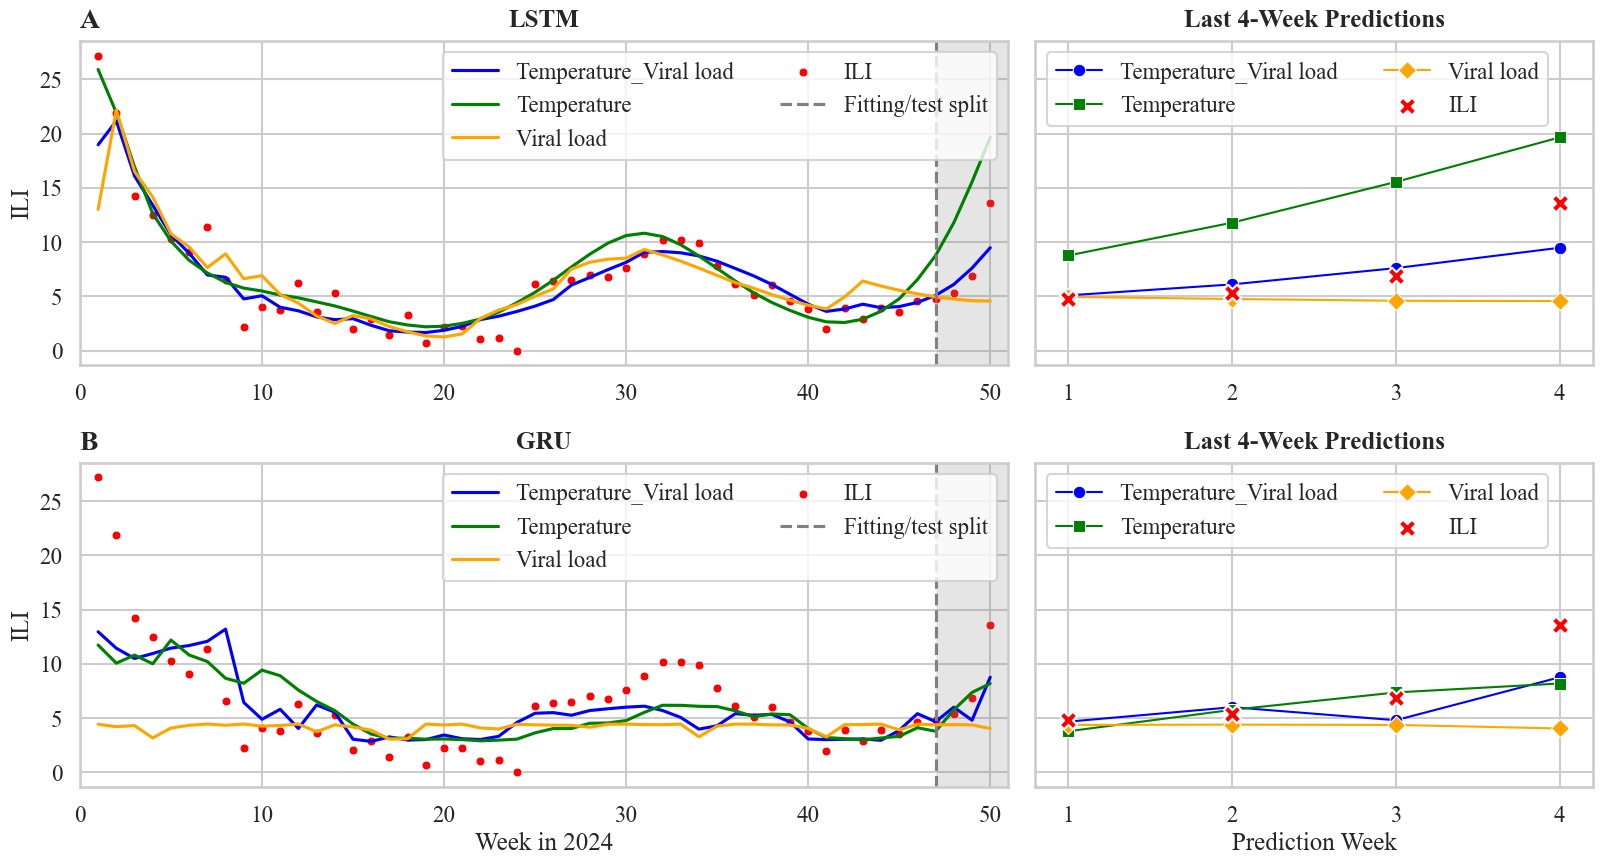

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'Times New Roman'

# =======================
# 1) LSTM 데이터 로드
# =======================
climate_water_lstm = pd.read_excel('../Data/prediction_result_all.xlsx')
climate_lstm = pd.read_excel('../Data/prediction_result_wea.xlsx')
water_lstm = pd.read_excel('../Data/prediction_result_water.xlsx')

df_cw_lstm = climate_water_lstm.iloc[52:].copy()
df_cl_lstm = climate_lstm.iloc[52:].copy()
df_wt_lstm = water_lstm.iloc[52:].copy()

train_size_lstm = len(df_cw_lstm) - 4
test_start_idx_lstm = df_cw_lstm.index[train_size_lstm]
split_week_lstm = df_cw_lstm.loc[test_start_idx_lstm, 'week']
x_start_lstm = df_cw_lstm['week'].iloc[0]
x_end_lstm = df_cw_lstm['week'].iloc[-1]
buffer = 1

df_cw_lstm_test = df_cw_lstm[df_cw_lstm['week'] >= split_week_lstm].copy()
df_cl_lstm_test = df_cl_lstm[df_cl_lstm['week'] >= split_week_lstm].copy()
df_wt_lstm_test = df_wt_lstm[df_wt_lstm['week'] >= split_week_lstm].copy()

df_cw_lstm_last4 = df_cw_lstm_test.tail(4).copy()
df_cl_lstm_last4 = df_cl_lstm_test.tail(4).copy()
df_wt_lstm_last4 = df_wt_lstm_test.tail(4).copy()

for d in [df_cw_lstm_last4, df_cl_lstm_last4, df_wt_lstm_last4]:
    d['x'] = [1, 2, 3, 4]

df_cw_lstm_last4['model'] = 'Temperature_Viral load'
df_cl_lstm_last4['model'] = 'Temperature'
df_wt_lstm_last4['model'] = 'Viral load'
df_lstm_last4_all = pd.concat([df_cw_lstm_last4, df_cl_lstm_last4, df_wt_lstm_last4], ignore_index=True)

# =======================
# 2) GRU 데이터 로드
# =======================
climate_water_gru = pd.read_excel('../Data/gru_pred_all.xlsx')
climate_gru = pd.read_excel('../Data/gru_pred_tem.xlsx')
water_gru = pd.read_excel('../Data/gru_pred_virus.xlsx')

df_cw_gru = climate_water_gru.iloc[52:].copy()
df_cl_gru = climate_gru.iloc[52:].copy()
df_wt_gru = water_gru.iloc[52:].copy()

train_size_gru = len(df_cw_gru) - 4
test_start_idx_gru = df_cw_gru.index[train_size_gru]
split_week_gru = df_cw_gru.loc[test_start_idx_gru, 'week']
x_start_gru = df_cw_gru['week'].iloc[0]
x_end_gru = df_cw_gru['week'].iloc[-1]

df_cw_gru_test = df_cw_gru[df_cw_gru['week'] >= split_week_gru].copy()
df_cl_gru_test = df_cl_gru[df_cl_gru['week'] >= split_week_gru].copy()
df_wt_gru_test = df_wt_gru[df_wt_gru['week'] >= split_week_gru].copy()

df_cw_gru_last4 = df_cw_gru_test.tail(4).copy()
df_cl_gru_last4 = df_cl_gru_test.tail(4).copy()
df_wt_gru_last4 = df_wt_gru_test.tail(4).copy()

for d in [df_cw_gru_last4, df_cl_gru_last4, df_wt_gru_last4]:
    d['x'] = [1, 2, 3, 4]

df_cw_gru_last4['model'] = 'Temperature_Viral load'
df_cl_gru_last4['model'] = 'Temperature'
df_wt_gru_last4['model'] = 'Viral load'
df_gru_last4_all = pd.concat([df_cw_gru_last4, df_cl_gru_last4, df_wt_gru_last4], ignore_index=True)

# =======================
# 3) 공통 스타일
# =======================
palette = {'Temperature_Viral load': 'blue', 'Temperature': 'green', 'Viral load': 'orange'}
marker_map = {'Temperature_Viral load': 'o', 'Temperature': 's', 'Viral load': 'D'}

# =======================
# 4) 2x2 한 번에 그리기
#    [0,0] LSTM 전체  [0,1] LSTM 마지막4주
#    [1,0] GRU  전체  [1,1] GRU  마지막4주
# =======================
fig, axs = plt.subplots(
    2, 2, figsize=(17, 9),
    sharey='row',
    gridspec_kw={'width_ratios': [2.5, 1.5]}
)

# ---------- (A) LSTM 전체 ----------
ax = axs[0, 0]
sns.lineplot(data=df_cw_lstm, x='week', y='pred_lstm_sca', label='Temperature_Viral load', color='blue', ax=ax)
sns.lineplot(data=df_cl_lstm, x='week', y='pred_lstm_sca', label='Temperature', color='green', ax=ax)
sns.lineplot(data=df_wt_lstm, x='week', y='pred_lstm_sca', label='Viral load', color='orange', ax=ax)
sns.scatterplot(data=df_cw_lstm, x='week', y='ILI', color='red', s=40, label='ILI', ax=ax)

ax.axvline(x=split_week_lstm, color='gray', linestyle='--', label='Fitting/test split')
ax.axvspan(split_week_lstm, x_end_lstm + buffer, facecolor='gray', alpha=0.2)

ax.set_xlim(x_start_lstm - buffer, x_end_lstm + buffer)
ax.set_title("LSTM", fontsize=18, fontweight='bold', pad=10)
ax.set_xlabel("")
ax.set_ylabel("ILI")
ax.legend(loc='upper right', ncol=2)
ax.text(0, 1.04, 'A', transform=ax.transAxes, weight='bold', fontsize=20)

# ---------- (B) LSTM 마지막 4주 ----------
ax = axs[0, 1]
for model in df_lstm_last4_all['model'].unique():
    sub_df = df_lstm_last4_all[df_lstm_last4_all['model'] == model]
    sns.lineplot(
        data=sub_df, x='x', y='pred_lstm_sca',
        label=model, color=palette[model],
        marker=marker_map[model], linewidth=1.5,
        ax=ax, zorder=1
    )
sns.scatterplot(
    data=df_cw_lstm_last4, x='x', y='ILI',
    color='red', s=160, label='ILI',
    marker='X', edgecolor='white', linewidth=1.5,
    ax=ax, zorder=10
)

ax.set_title("Last 4-Week Predictions", fontsize=18, fontweight='bold', pad=10)
ax.set_xlabel("")
ax.set_xticks([1, 2, 3, 4])
ax.set_xlim(0.8, 4.2)
ax.legend(loc='upper left', ncol=2)
# ax.text(0, 1.04, 'B', transform=ax.transAxes, weight='bold', fontsize=20)

# ---------- (C) GRU 전체 ----------
ax = axs[1, 0]
sns.lineplot(data=df_cw_gru, x='week', y='gru_pred', label='Temperature_Viral load', color='blue', ax=ax)
sns.lineplot(data=df_cl_gru, x='week', y='gru_pred', label='Temperature', color='green', ax=ax)
sns.lineplot(data=df_wt_gru, x='week', y='gru_pred', label='Viral load', color='orange', ax=ax)
sns.scatterplot(data=df_cw_gru, x='week', y='ILI', color='red', s=40, label='ILI', ax=ax)

ax.axvline(x=split_week_gru, color='gray', linestyle='--', label='Fitting/test split')
ax.axvspan(split_week_gru, x_end_gru + buffer, facecolor='gray', alpha=0.2)

ax.set_xlim(x_start_gru - buffer, x_end_gru + buffer)
ax.set_title("GRU", fontsize=18, fontweight='bold', pad=10)
ax.set_xlabel("Week in 2024")
ax.set_ylabel("ILI")
ax.legend(loc='upper right', ncol=2)
ax.text(0, 1.04, 'B', transform=ax.transAxes, weight='bold', fontsize=20)

# ---------- (D) GRU 마지막 4주 ----------
ax = axs[1, 1]
for model in df_gru_last4_all['model'].unique():
    sub_df = df_gru_last4_all[df_gru_last4_all['model'] == model]
    sns.lineplot(
        data=sub_df, x='x', y='gru_pred',
        label=model, color=palette[model],
        marker=marker_map[model], linewidth=1.5,
        ax=ax, zorder=1
    )
sns.scatterplot(
    data=df_cw_gru_last4, x='x', y='ILI',
    color='red', s=160, label='ILI',
    marker='X', edgecolor='white', linewidth=1.5,
    ax=ax, zorder=10
)

ax.set_title("Last 4-Week Predictions", fontsize=18, fontweight='bold', pad=10)
ax.set_xlabel("Prediction Week")
ax.set_xticks([1, 2, 3, 4])
ax.set_xlim(0.8, 4.2)
ax.legend(loc='upper left', ncol=2)
#ax.text(0, 1.04, 'D', transform=ax.transAxes, weight='bold', fontsize=20)

plt.tight_layout()
plt.savefig("../figure/figure 3.png", dpi=600, bbox_inches=None, pad_inches=0)
plt.show()

## 증강데이터를 사용한 결과

In [ ]:
final_result=pd.read_excel('../Data/predictions_1000_augmentations_all_good.xlsx')

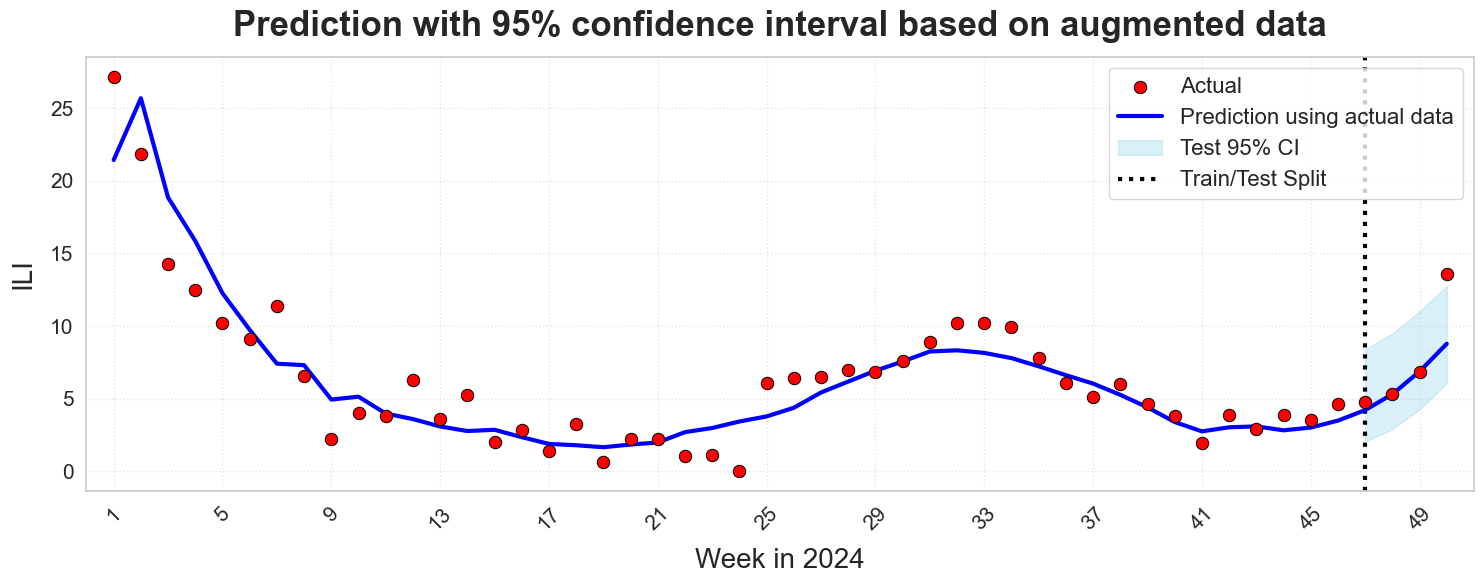

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Seaborn 스타일 적용
sns.set(style="whitegrid")

plt.figure(figsize=(15, 6))

# 실제값: 빨간 점 + 검은 외곽선
sns.scatterplot(
    data=final_result,
    x=final_result.index, y="actual",
    s=80, color="red", edgecolor="black", linewidth=0.7,
    label="Actual", zorder=4
)

# 기준 예측선: viral_A_101__avgtem_101
pat_101 = re.compile(r'^viral_A_101__avgtem_101$')
cand_101 = [c for c in final_result.columns if pat_101.match(c)]
col_101 = cand_101[0]

sns.lineplot(
    data=final_result,
    x=final_result.index, y=col_101,
    linewidth=3, color="blue",
    label="Prediction using actual data", zorder=3
)

# CI: 마지막 4개만 fill_between
n = 4
x_ci = final_result.index[-n:]
y_lower = final_result["ci_lower"].iloc[-n:]
y_upper = final_result["ci_upper"].iloc[-n:]

plt.fill_between(x_ci, y_lower, y_upper, color="skyblue", alpha=0.3, label="Test 95% CI", zorder=2)

# 세로선: Train/Test Split
boundary = len(final_result) - 4
plt.axvline(x=boundary, color="black", linestyle=":", linewidth=3, label="Train/Test Split")

# 그래프 설정
plt.title("Prediction with 95% confidence interval based on augmented data", fontsize=25, fontweight="bold", pad=15)
plt.xlabel("Week in 2024", fontsize=20, labelpad=10)
plt.xticks(final_result.index[::4], final_result["week"][::4], rotation=45, fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("ILI", fontsize=20, labelpad=10)
plt.legend(fontsize=16, loc="upper right")
plt.xlim(final_result.index[0]-1, final_result.index[-1]+1)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()
